In [1]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

# NumPy is used for numerical operations and array handling
import numpy as np

# Pandas is used for loading and manipulating datasets
import pandas as pd





In [2]:
#! pip install tensorflow



In [3]:
import tensorflow as tf

In [4]:
# ============================================================
# 2. CHECK TENSORFLOW VERSION
# ============================================================

# Display the installed TensorFlow version
tf.__version__


'2.21.0'

In [5]:


# Load the Churn Modelling dataset
dataset = pd.read_csv(
"C:/kunal/GIthub/FSDS-Adv-GenAI-and-Adv-Agentic-AI/Deep Learning/NIT/Churn_Modelling.csv"
)

# Display the first 5 rows
dataset.head()

,apst,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,delhi,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,bangalore,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,delhi,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,delhi,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,bangalore,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Number of rows and columns
print("Shape:", dataset.shape)

# Column names
print("\nColumns:")
print(dataset.columns.tolist())

# Dataset information
print("\nDataset Info:")
dataset.info()

Shape: (10000, 14)

Columns:
['apst', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   apst             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000

In [29]:
dataset.describe()

,apst,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
# Input features
X = dataset.iloc[:, 3:-1].values

# Target variable
y = dataset.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [30]:
dataset.isna().sum()

apst               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode the Gender column
# X[:, 2] → selects the 3rd column of X (Gender)
X[:, 2] = le.fit_transform(X[:, 2])

In [9]:
X

array([[619, 'delhi', 0, ..., 1, 1, 101348.88],
       [608, 'bangalore', 0, ..., 0, 1, 112542.58],
       [502, 'delhi', 0, ..., 1, 0, 113931.57],
       ...,
       [709, 'delhi', 0, ..., 0, 1, 42085.58],
       [772, 'mumbai', 1, ..., 1, 0, 92888.52],
       [792, 'delhi', 0, ..., 1, 0, 38190.78]],
      shape=(10000, 10), dtype=object)

In [10]:
# ============================================================
# ONE-HOT ENCODING FOR GEOGRAPHY
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a ColumnTransformer
# [1] means the 2nd column of X → Geography
#
# OneHotEncoder() converts categorical values such as:
# France, Germany, Spain
# into separate binary columns.
#
# remainder='passthrough' keeps all other columns unchanged.

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [1])
    ],
    remainder='passthrough'
)

# Apply the transformation to X
# Convert the resulting data into a NumPy array
X = np.array(ct.fit_transform(X))

In [11]:
X

array([[0.0, 1.0, 0.0, ..., 1, 1, 101348.88],
       [1.0, 0.0, 0.0, ..., 0, 1, 112542.58],
       [0.0, 1.0, 0.0, ..., 1, 0, 113931.57],
       ...,
       [0.0, 1.0, 0.0, ..., 0, 1, 42085.58],
       [0.0, 0.0, 1.0, ..., 1, 0, 92888.52],
       [0.0, 1.0, 0.0, ..., 1, 0, 38190.78]],
      shape=(10000, 12), dtype=object)

In [12]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
sc = StandardScaler()

# Fit the scaler on X and transform all features
X = sc.fit_transform(X)

In [13]:
X

array([[-0.57380915,  0.99720391, -0.57873591, ...,  0.64609167,
         0.97024255,  0.02188649],
       [ 1.74273971, -1.00280393, -0.57873591, ..., -1.54776799,
         0.97024255,  0.21653375],
       [-0.57380915,  0.99720391, -0.57873591, ...,  0.64609167,
        -1.03067011,  0.2406869 ],
       ...,
       [-0.57380915,  0.99720391, -0.57873591, ..., -1.54776799,
         0.97024255, -1.00864308],
       [-0.57380915, -1.00280393,  1.72790383, ...,  0.64609167,
        -1.03067011, -0.12523071],
       [-0.57380915,  0.99720391, -0.57873591, ...,  0.64609167,
        -1.03067011, -1.07636976]], shape=(10000, 12))

In [14]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
#
# test_size=0.2
# → 80% data is used for training
# → 20% data is used for testing
#
# random_state=0
# → Ensures the same split every time the code runs

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)


# ============================================================
# CHECK THE SHAPE OF EACH DATASET
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (8000, 12)
X_test shape : (2000, 12)
y_train shape: (8000,)
y_test shape : (2000,)


<h1 style="
    text-align:center;
    font-size:42px;
    font-weight:900;
    color:#FFF5F7;
    background:linear-gradient(90deg,#4A0E1A,#800F2F,#A4133C);
    border:4px solid #FFD166;
    border-radius:16px;
    padding:22px;
    letter-spacing:1px;
    text-shadow:2px 2px 5px #000000;
">
    🧠 ANN MODEL BUILDING ARCHITECTURE
</h1>

In [15]:
# ============================================================
# ANN MODEL BUILDING
# ============================================================

# Create a Sequential neural network
# Sequential means layers are added one after another
ann = tf.keras.models.Sequential()




In [16]:
# ============================================================
# INPUT LAYER
# ============================================================

# Define the number of input features
# X_train.shape[1] = number of features after encoding
ann.add(
    tf.keras.Input(shape=(X_train.shape[1],))
)




In [17]:
# ============================================================
# HIDDEN LAYER 1
# ============================================================

# Add the first hidden layer
# units=6       → 6 neurons
# activation     → ReLU
ann.add(
    tf.keras.layers.Dense(
        units=6,
        activation='relu'
    )
)




In [18]:
# ============================================================
# HIDDEN LAYER 2
# ============================================================

# Add the second hidden layer
# units=5       → 5 neurons
# activation     → ReLU
ann.add(
    tf.keras.layers.Dense(
        units=5,
        activation='relu'
    )
)




In [19]:
# ============================================================
# HIDDEN LAYER 3
# ============================================================

# Add the third hidden layer
# units=4       → 4 neurons
# activation     → ReLU
ann.add(
    tf.keras.layers.Dense(
        units=4,
        activation='relu'
    )
)




In [20]:
# ============================================================
# OUTPUT LAYER
# ============================================================

# Binary classification → 1 output neuron
# sigmoid converts the output into a probability between 0 and 1
ann.add(
    tf.keras.layers.Dense(
        units=1,
        activation='sigmoid'
    )
)

In [21]:
# ============================================================
# COMPILE THE ANN MODEL
# ============================================================

# Configure the ANN for training
ann.compile(
    optimizer='adam',                  # Optimizer used to update weights
    loss='binary_crossentropy',        # Loss function for binary classification
    metrics=['accuracy']               # Evaluation metric
)




In [22]:
# ============================================================
# TRAIN THE ANN MODEL
# ============================================================

# Train the neural network using the training dataset
ann.fit(
    X_train,        # Training input features
    y_train,        # Training target values
    batch_size=32,  # Number of samples processed before updating weights
    epochs=70       # Number of complete passes through the training dataset
)

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7960 - loss: 0.5573
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4646
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4462
Epoch 4/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4361
Epoch 5/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.4280
Epoch 6/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4206
Epoch 7/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4137
Epoch 8/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8061 - loss: 0.4069
Epoch 9/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8139 - loss: 0.3996
Epoch 10/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8306 - loss: 0.3927
Epoch 11/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8361 - loss: 0.3861
Epoch 12/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [23]:
# ============================================================
# PREDICTION AND COMPARISON
# ============================================================

# Predict churn probability
y_pred = ann.predict(X_test)

# Convert probability to 0/1 class using 0.5 threshold
y_pred = (y_pred > 0.5)

# Compare predicted values with actual values
print(
    np.concatenate(
        (
            y_pred.reshape(len(y_pred), 1),
            y_test.reshape(len(y_test), 1)
        ),
        axis=1
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [24]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
print(cm)

[[1513   82]
 [ 189  216]]


In [25]:
# ============================================================
# CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

Accuracy : 86.45%
Precision: 72.48%
Recall   : 53.33%
F1 Score : 61.45%


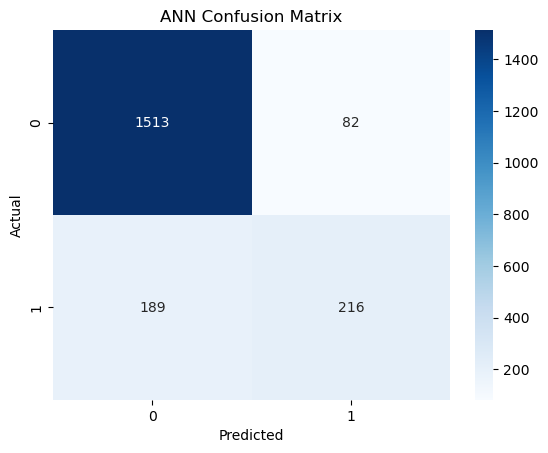

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()

## ANN Confusion Matrix

The confusion matrix shows how well the ANN model classified the test data.

| Actual | Predicted 0 | Predicted 1 |
|--------|-------------|-------------|
| 0      | 1498 (TN)   | 97 (FP)     |
| 1      | 188 (FN)    | 217 (TP)    |

### Explanation

- **TN = 1498** → Customer did not leave, and model correctly predicted 0.
- **FP = 97** → Customer did not leave, but model predicted 1.
- **FN = 188** → Customer left, but model predicted 0.
- **TP = 217** → Customer left, and model correctly predicted 1.

### Conclusion

The model correctly predicted **1498 + 217 = 1715** customers.

The model made **97 + 188 = 285** incorrect predictions.

The confusion matrix helps us understand the model's classification performance.

In [27]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

# Display precision, recall, F1-score and support
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1595
           1       0.72      0.53      0.61       405

    accuracy                           0.86      2000
   macro avg       0.81      0.74      0.77      2000
weighted avg       0.86      0.86      0.86      2000



## Classification Report

The classification report provides the main performance metrics of the ANN model.

- **Precision** → How many predicted positive cases were actually positive.
- **Recall** → How many actual positive cases were correctly identified.
- **F1-score** → Balance between precision and recall.
- **Support** → Number of actual samples in each class.
- **Accuracy** → Overall percentage of correct predictions.

For churn prediction, **Recall for class 1** is important because it shows how many customers who actually left were correctly identified.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC Score: 0.8693277603622431


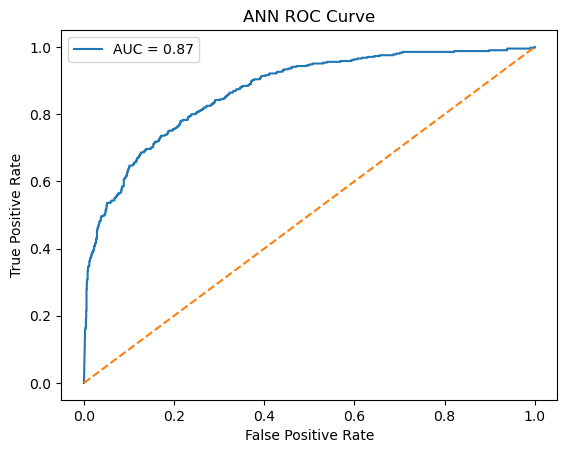

In [28]:
# ============================================================
# ROC CURVE AND AUC SCORE
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get churn probabilities
y_prob = ann.predict(X_test).ravel()

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend()
plt.show()

## ROC Curve and AUC

- **ROC Curve** shows the performance of the classification model at different probability thresholds.
- **AUC** stands for Area Under the ROC Curve.
- AUC closer to **1** indicates better classification performance.
- AUC around **0.5** means the model performs approximately like random guessing.

For churn prediction, ROC-AUC helps evaluate how well the ANN separates customers who stay from customers who leave.

In [31]:
# ============================================================
# SAVE ANN MODEL
# ============================================================

# Save the trained ANN model
ann.save("churn_ann_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [32]:
# Check model architecture and parameters
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.68 KB)

 Trainable params: 142 (568.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 286 (1.12 KB)

In [33]:
# ============================================================
# LOAD SAVED MODEL
# ============================================================

from tensorflow.keras.models import load_model

# Load the trained ANN model
loaded_model = load_model("churn_ann_model.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [34]:
y_pred = loaded_model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
